# GoalLab Stage 12: Select among frozen-policy briefings

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 11](11_tool_gateway_integration.ipynb) · [Stage 13](13_budgeted_reasoning_search.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/notebooks/12_sampling_and_selection.ipynb)

**Build:** compare completed briefing candidates proposed by a frozen policy. The candidates now use GoalLab sources, extraction, and citations.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 12](../../../notebooks/12_sampling_and_selection.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Separate candidate opportunity from selection; calculate scoring costs; test a scorer without changing proposals.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: opportunity is not selected success

The frozen proposer chooses the older authoritative source with probability 0.25, extracts exactly with probability 0.65, and matches its citation with probability 0.8. In the default generator, a single complete candidate therefore succeeds with probability 0.13.

For independent candidates, the chance that at least one succeeds is `1-(1-p)^N`. A selector can only realize that opportunity if it identifies the successful candidate. This formula is not a guarantee about correlated LLM generations.

In [2]:
p=.25*.65*.8
table(['Candidates','Oracle success opportunity'],[[n,1-(1-p)**n] for n in [1,4,6,12]])
print('At budget 24: unscored candidates =',24//3,'; scored candidates =',24//4)
assert np.isclose(p,.13)

| Candidates | Oracle success opportunity |
|---|---|
| 1 | 0.13 |
| 4 | 0.42710239000000005 |
| 6 | 0.566373798991 |
| 12 | 0.8119683177985023 |

At budget 24: unscored candidates = 8 ; scored candidates = 6


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from rl_course import goallab_search as search
import random
def candidate_pool(workspace, count, seed=7):
    proposer=search.FrozenProposer()
    rng=random.Random(seed)
    candidates=[]
    for _ in range(count):
        session=goal.Session(workspace,4); prefix=()
        for decision in range(3):
            action=proposer.propose(session,prefix,rng)
            if decision==0: session.execute('read',action)
            prefix += (action,)
        candidates.append((search.artifact(session,prefix),search.score(session,prefix)))
    return candidates
pool=candidate_pool(workspace,4)
assert [a for a,score in pool]==search.search(workspace,'best_of_n',16,7)['candidates']
table(['Candidate','Evidence score'],[[a,s] for a,s in pool])

| Candidate | Evidence score |
|---|---|
| Briefing(value=21, citation='test-7-source-0', period='2026-02', abstained=False) | 0.6666666666666666 |
| Briefing(value=21, citation='test-7-source-0', period='2026-02', abstained=False) | 0.6666666666666666 |
| Briefing(value=21, citation='test-7-source-0', period='2026-02', abstained=False) | 0.6666666666666666 |
| Briefing(value=21, citation='test-7-source-0', period='2026-02', abstained=False) | 0.6666666666666666 |

## 1. Candidate generation versus selection

The reference proposer is a fixed categorical policy, not an LLM: it favors the newest source with probability 0.75, extracts exactly with probability 0.65, and matches its citation with probability 0.8. This intentionally weak policy makes selection effects inspectable. It reads through the shared session engine.

A candidate has three decisions: source, extraction offset, citation. Single sampling chooses one; self-consistency votes on the numerical answer; best-of-N ranks full candidates using visible evidence checks. A wrong majority can become more stable with more samples.

| Method | Budget | Verified success | Oracle opportunity | Spent | Completion |
|---|---|---|---|---|---|
| single | 6 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 6 | 0.133 | 0.233 | 6.0 | 1.0 |
| best_of_n | 6 | 0.133 | 0.133 | 4.0 | 1.0 |
| single | 12 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 12 | 0.079 | 0.388 | 12.0 | 1.0 |
| best_of_n | 12 | 0.308 | 0.308 | 12.0 | 1.0 |
| single | 24 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 24 | 0.067 | 0.679 | 24.0 | 1.0 |
| best_of_n | 24 | 0.558 | 0.558 | 24.0 | 1.0 |
| single | 48 | 0.133 | 0.133 | 3.0 | 1.0 |
| self_consistency | 48 | 0.042 | 0.9 | 48.0 | 1.0 |
| best_of_n | 48 | 0.817 | 0.817 | 48.0 | 1.0 |

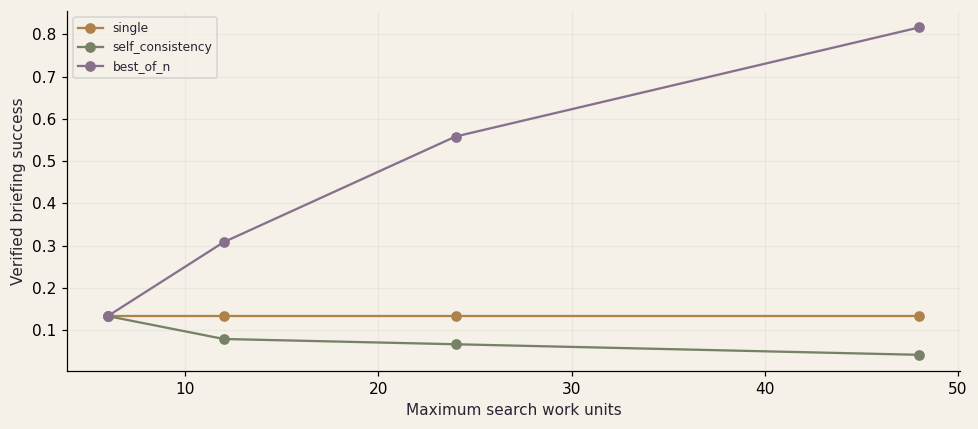

In [4]:
from rl_course import goallab_search as search
def summarize(rows):
    groups={}
    for r in rows: groups.setdefault((r['method'],r['budget']),[]).append(r)
    table(['Method','Budget','Verified success','Oracle opportunity','Spent','Completion'],
          [[m,b,*[round(np.mean([r[k] for r in rs]),3) for k in ['success','oracle','spent','completion']]] for (m,b),rs in groups.items()])
def search_plot(rows):
    for method in dict.fromkeys(r['method'] for r in rows):
        group=[r for r in rows if r['method']==method]
        budgets=sorted({r['budget'] for r in group})
        plt.plot(budgets,[np.mean([r['success'] for r in group if r['budget']==b]) for b in budgets],marker='o',label=method)
    plt.xlabel('Maximum search work units'); plt.ylabel('Verified briefing success'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

rows=search.benchmark(cases=80,methods=('single','self_consistency','best_of_n'))
summarize(rows); search_plot(rows)

## 2. Match candidate counts before blaming the selector

Four unscored candidates cost 12 units. Four scored candidates cost 16 at one unit per full-candidate score. With the same seed they must have identical candidate artifacts. Final verification is used only after selection.

In [5]:
voting=search.search(workspace,'self_consistency',12,7)
ranked=search.search(workspace,'best_of_n',16,7)
assert voting['candidates']==ranked['candidates']
for label,r in [('Voting',voting),('Ranking',ranked)]:
    print(label,r['artifact'],goal.verify(workspace,r['artifact']),r['spent'])

Voting Briefing(value=21, citation='test-7-source-0', period='2026-02', abstained=False) {'success': False, 'supported': False, 'value_correct': False} 12
Ranking Briefing(value=21, citation='test-7-source-0', period='2026-02', abstained=False) {'success': False, 'supported': False, 'value_correct': False} 16


## Interpret the evidence

At the default proposal probabilities, more voting can reinforce the wrong source. The exact evidence checker can select a correct candidate when one exists under this schema, but a realistic fallible verifier may not realize that opportunity.

## Change a constraint: predict first

Keep candidates fixed but reward recency instead of authority. Predict whether oracle candidate opportunity changes.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
bad=search.search(workspace,'best_of_n',16,7,signal='misleading')
assert bad['candidates']==ranked['candidates']
print('Evidence selection:',goal.verify(workspace,ranked['artifact']))
print('Recency selection:',goal.verify(workspace,bad['artifact']))
print('Opportunity is unchanged because candidate generation is identical; the selected artifact may change.')

Evidence selection: {'success': False, 'supported': False, 'value_correct': False}
Recency selection: {'success': False, 'supported': False, 'value_correct': False}
Opportunity is unchanged because candidate generation is identical; the selected artifact may change.


## What this stage contributes

A frozen-policy candidate selector for the same briefing task. Theory: [candidate selection](../../../chapters/43-sampling-and-candidate-selection/README.md).

[Stage 11](11_tool_gateway_integration.ipynb) · [Stage 13](13_budgeted_reasoning_search.ipynb)